<h2  align='center'>Pistachio Image Classification</h2>

In [1]:
import numpy as np
from sklearn.metrics import confusion_matrix , classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory("..\\Pistachio_Image_Dataset/Pistachio_Image_Dataset",
                                                       validation_split=0.2,subset="training",seed=42,image_size=(128, 128),batch_size=32)

Found 2148 files belonging to 2 classes.
Using 1719 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory("..\\Pistachio_Image_Dataset/Pistachio_Image_Dataset",
                                                     validation_split=0.2, subset="validation",seed=42,image_size=(128, 128),batch_size=32
)

Found 2148 files belonging to 2 classes.
Using 429 files for validation.


In [101]:
class_names = train_ds.class_names

In [102]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['Kirmizi_Pistachio', 'Siirt_Pistachio']


In [103]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [104]:
model = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    layers.Rescaling(1.0 / 255),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(2, activation="softmax"),
])


In [105]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [113]:
early_stop = EarlyStopping(
    monitor='val_loss',        
    patience=8,                
    restore_best_weights=True  
)

In [114]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop] 
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.7946 - loss: 0.4429 - val_accuracy: 0.8089 - val_loss: 0.4178
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.8005 - loss: 0.4430 - val_accuracy: 0.8252 - val_loss: 0.3864
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.8045 - loss: 0.4324 - val_accuracy: 0.8205 - val_loss: 0.4223
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.7970 - loss: 0.4291 - val_accuracy: 0.8042 - val_loss: 0.4147
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.8133 - loss: 0.4216 - val_accuracy: 0.8368 - val_loss: 0.3767
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.8191 - loss: 0.3959 - val_accuracy: 0.8438 - val_loss: 0.3698
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.8028 - loss: 0.4262 - val_accuracy: 0.8462 - val_loss: 0.3890
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.8261 - loss: 0.3940 - val_accu

In [115]:
model.save("pistachio_model.keras")
print("Model saved to pistachio_model.keras")

Model saved to pistachio_model.keras


In [116]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation accuracy: {val_acc:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9510 - loss: 0.1249
Validation accuracy: 0.9510


In [117]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


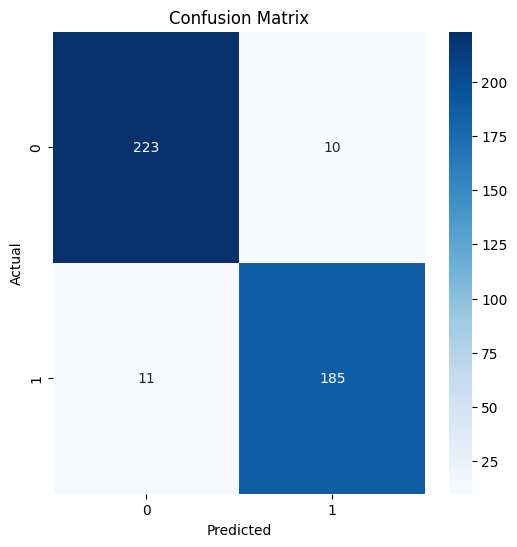

In [118]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [119]:
print(classification_report(y_true, y_pred, target_names=class_names))

                   precision    recall  f1-score   support

Kirmizi_Pistachio       0.95      0.96      0.96       233
  Siirt_Pistachio       0.95      0.94      0.95       196

         accuracy                           0.95       429
        macro avg       0.95      0.95      0.95       429
     weighted avg       0.95      0.95      0.95       429

